In [86]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms,models
from sklearn.metrics import accuracy_score
from PIL import Image
from scipy.stats import beta
import numpy as np
from collections import Counter
import torch.nn.functional as F
import kagglehub
import matplotlib.pyplot as plt

In [54]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)
BASE = "/kaggle/input/chest-xray-pneumonia/chest_xray"

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [55]:
device = torch.device ('cuda' if torch.cuda.is_available() else 'cpu')

##Dataset

In [56]:
class PneumoniaDataset(Dataset):
  def __init__(self, root_dir, transform=None):
    self.root_dir = root_dir
    self.transform= transform
    self.image_paths=[]
    self.labels=[]

    for label in ['NORMAL', 'PNEUMONIA']:
      class_dir = os.path.join(root_dir, label)
      for img_name in os.listdir(class_dir):
        self.image_paths.append(os.path.join(class_dir, img_name))
        self.labels.append(0 if label == 'NORMAL' else 1)


  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):
    img_path = self.image_paths[idx]
    image = Image.open(img_path).convert('RGB')
    label=self.labels[idx]

    if self.transform:
      image = self.transform(image)

    return image, label

In [57]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])
val_transform=train_transform

In [58]:
train_dataset= PneumoniaDataset(root_dir=os.path.join(BASE, 'train'), transform=train_transform)
test_dataset= PneumoniaDataset(root_dir=os.path.join(BASE, 'test'), transform=test_transform)
val_dataset= PneumoniaDataset(root_dir=os.path.join(BASE, 'val'), transform=val_transform)

In [59]:
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

###Handling Class Imbalance

In [60]:
class_counts = Counter(train_dataset.labels)
print(class_counts)

Counter({1: 3875, 0: 1341})


In [61]:
num_samples = sum(class_counts.values())

class_weights = torch.tensor([
    num_samples / (2 * class_counts[0]),
    num_samples / (2 * class_counts[1])
], dtype=torch.float32).to(device)

print(class_weights)

tensor([1.9448, 0.6730], device='cuda:0')


## Model Architecture

In [62]:
class DenseDirichlet(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.linear = nn.Linear(in_features, num_classes)

    def forward(self, x):
        logits = self.linear(x)

        # Softplus is generally preferred over exp
        evidence = torch.nn.functional.softplus(logits)

        alpha = evidence + 1

        return alpha

In [74]:
class EvidentialLoss(nn.Module):

    def __init__(self, num_classes, class_weights= None, annealing_step=10):
        super().__init__()

        self.num_classes = num_classes
        self.class_weights = class_weights
        self.annealing_step = annealing_step
        self.current_epoch = 0

    def KL(self, alpha):

        beta = torch.ones((1, alpha.size(1)),
                          device=alpha.device,
                          dtype=alpha.dtype)

        S_alpha = torch.sum(alpha, dim=1, keepdim=True)
        S_beta = torch.sum(beta, dim=1, keepdim=True)

        lnB = (
            torch.lgamma(S_alpha)
            - torch.sum(torch.lgamma(alpha), dim=1, keepdim=True)
        )

        lnB_uni = (
            torch.sum(torch.lgamma(beta), dim=1, keepdim=True)
            - torch.lgamma(S_beta)
        )

        dg0 = torch.digamma(S_alpha)
        dg1 = torch.digamma(alpha)

        kl = torch.sum(
            (alpha - beta) * (dg1 - dg0),
            dim=1,
            keepdim=True
        )

        kl = kl + lnB + lnB_uni

        return kl

    def forward(self, alpha, target):

        y = F.one_hot(
            target,
            num_classes=self.num_classes
        ).float()

        S = torch.sum(alpha, dim=1, keepdim=True)

        m = alpha / S

        evidence = alpha - 1

        A = torch.sum(
            (y - m) ** 2,
            dim=1,
            keepdim=True
        )

        B = torch.sum(
            alpha * (S - alpha) /
            (S * S * (S + 1)),
            dim=1,
            keepdim=True
        )

        alpha_hat = y + (1 - y) * alpha

        C = self.KL(alpha_hat)
        annealing_coef = min(
            1.0,
            self.current_epoch / self.annealing_step
        )
        loss = A + B + annealing_coef * C
        if self.class_weights is not None:
            sample_weights = self.class_weights[target]
            loss = loss.squeeze() * sample_weights
        return loss.mean()

In [75]:
class EvidentialDenseNet(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.densenet121(weights="IMAGENET1K_V1")

        self.features = base.features

        #Changes

        for param in self.features.parameters():
          param.requires_grad= False

        #Changes

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.classifier = DenseDirichlet(
            in_features=1024,
            num_classes=2
        )

    def forward(self,x):

        x = self.features(x)

        x = torch.relu(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        alpha = self.classifier(x)

        return alpha

In [76]:
model = EvidentialDenseNet().to(device)

learning_rate = 3e-5

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

criterion = EvidentialLoss(num_classes=2, class_weights = class_weights)

## Training

In [77]:
num_epochs=8

In [78]:
for epoch in range(num_epochs):
  if epoch == 3:
    for param in model.features.parameters():
      param.requires_grad=True
  criterion.current_epoch = epoch
  #Training
  model.train()
  running_loss=0.0
  train_labels = []
  train_preds = []

  for images, labels in train_loader:
    images=images.to(device)
    labels=labels.to(device)

    optimizer.zero_grad()
    alpha = model(images)
    probs = alpha / alpha.sum(dim=1, keepdim=True)
    S = alpha.sum(dim=1)
    uncertainty = 2.0 / S
    #evidence = alpha - 1
    preds = probs.argmax(dim=1)
    train_labels.extend(labels.cpu().numpy())
    train_preds.extend(preds.cpu().numpy())
    train_uncertainties = uncertainty.detach().cpu().numpy().flatten()
    loss=criterion(alpha, labels)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()

  epoch_loss=running_loss/len(train_loader)
  train_acc = accuracy_score(train_labels, train_preds)
  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Train Accuracy: {train_acc:.4f}")

#Validation

  model.eval()
  val_labels=[]
  val_preds=[]
  val_uncertainties =[]
  with torch.no_grad():
    for images, labels in val_loader:
      images=images.to(device)
      labels=labels.to(device)

      alpha = model(images)
      probs = alpha / alpha.sum(dim=1, keepdim=True)
      S = alpha.sum(dim=1)
      uncertainty = 2.0 / S
      #evidence = alpha - 1
      preds = probs.argmax(dim=1)
      val_labels.extend(labels.cpu().numpy())
      val_preds.extend(preds.cpu().numpy())
      val_uncertainties.extend(uncertainty.detach().cpu().numpy().flatten())

  val_acc=accuracy_score(val_labels, val_preds)
  print(f"Validation Accuracy: {val_acc:.4f}")


Epoch [1/8], Loss: 0.5903, Train Accuracy: 0.7339
Validation Accuracy: 0.5625
Epoch [2/8], Loss: 0.5763, Train Accuracy: 0.7901
Validation Accuracy: 0.6250
Epoch [3/8], Loss: 0.5698, Train Accuracy: 0.8238
Validation Accuracy: 0.6875
Epoch [4/8], Loss: 0.2176, Train Accuracy: 0.9358
Validation Accuracy: 0.8125
Epoch [5/8], Loss: 0.1123, Train Accuracy: 0.9668
Validation Accuracy: 1.0000
Epoch [6/8], Loss: 0.0892, Train Accuracy: 0.9737
Validation Accuracy: 0.9375
Epoch [7/8], Loss: 0.0855, Train Accuracy: 0.9747
Validation Accuracy: 0.8750
Epoch [8/8], Loss: 0.0725, Train Accuracy: 0.9791
Validation Accuracy: 1.0000


In [87]:
model.eval()
test_labels=[]
test_preds=[]
test_uncertainties = []
test_alphas = []
test_correct= []
test_images = []
test_confidences = []
with torch.no_grad():
  for images, labels in test_loader:
    images=images.to(device)
    test_images.extend(images.cpu())
    labels=labels.to(device)
    alpha = model(images)
    probs = alpha / alpha.sum(dim=1, keepdim=True)
    S = alpha.sum(dim=1)
    uncertainty = 2.0 / S
    #evidence = alpha - 1
    confidence, preds = probs.max(dim=1)
    test_correct.extend((preds==labels).cpu().numpy())
    test_labels.extend(labels.cpu().numpy())
    test_preds.extend(preds.cpu().numpy())
    test_uncertainties.extend(uncertainty.detach().cpu().numpy().flatten())
    test_alphas.extend(alpha.detach().cpu().numpy())
    test_confidences.extend(confidence.detach().cpu().numpy())
test_acc=accuracy_score(test_labels, test_preds)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9087


#Visualization

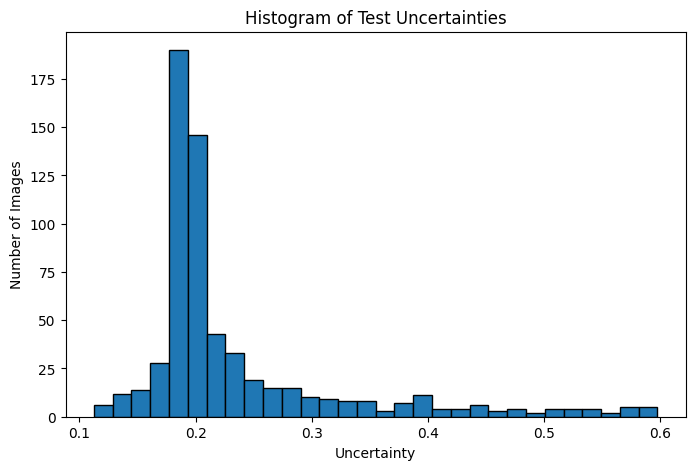

In [88]:
# Uncertainity Histogram
plt.figure(figsize=(8,5))

plt.hist(
    test_uncertainties,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Uncertainty")
plt.ylabel("Number of Images")
plt.title("Histogram of Test Uncertainties")

plt.show()

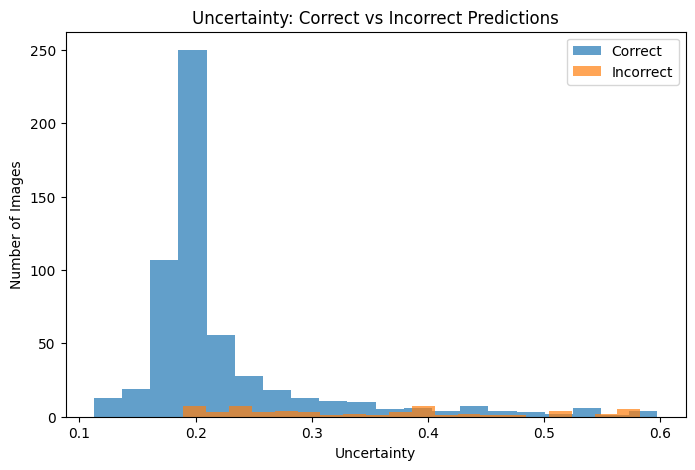

In [89]:
correct_unc = [
    u for u, c in zip(test_uncertainties, test_correct)
    if c
]

incorrect_unc = [
    u for u, c in zip(test_uncertainties, test_correct)
    if not c
]

plt.figure(figsize=(8,5))

plt.hist(
    correct_unc,
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    incorrect_unc,
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel("Uncertainty")
plt.ylabel("Number of Images")
plt.title("Uncertainty: Correct vs Incorrect Predictions")

plt.legend()

plt.show()

In [90]:
mean_correct = np.mean(correct_unc)
mean_incorrect = np.mean(incorrect_unc)

print(f"Mean uncertainty (Correct):   {mean_correct:.4f}")
print(f"Mean uncertainty (Incorrect): {mean_incorrect:.4f}")

Mean uncertainty (Correct):   0.2234
Mean uncertainty (Incorrect): 0.3517


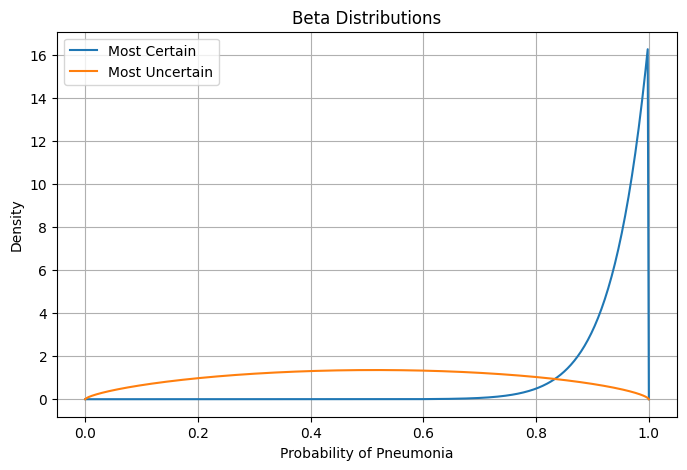

In [91]:
#Beta Distribution

# Most certain sample
min_idx = np.argmin(test_uncertainties)

# Most uncertain sample
max_idx = np.argmax(test_uncertainties)

x = np.linspace(0, 1, 500)

plt.figure(figsize=(8,5))

# Most certain
a, b = test_alphas[min_idx]
plt.plot(
    x,
    beta.pdf(x, a, b),
    label="Most Certain"
)

# Most uncertain
a, b = test_alphas[max_idx]
plt.plot(
    x,
    beta.pdf(x, a, b),
    label="Most Uncertain"
)

plt.xlabel("Probability of Pneumonia")
plt.ylabel("Density")
plt.title("Beta Distributions")

plt.legend()

plt.grid(True)

plt.show()

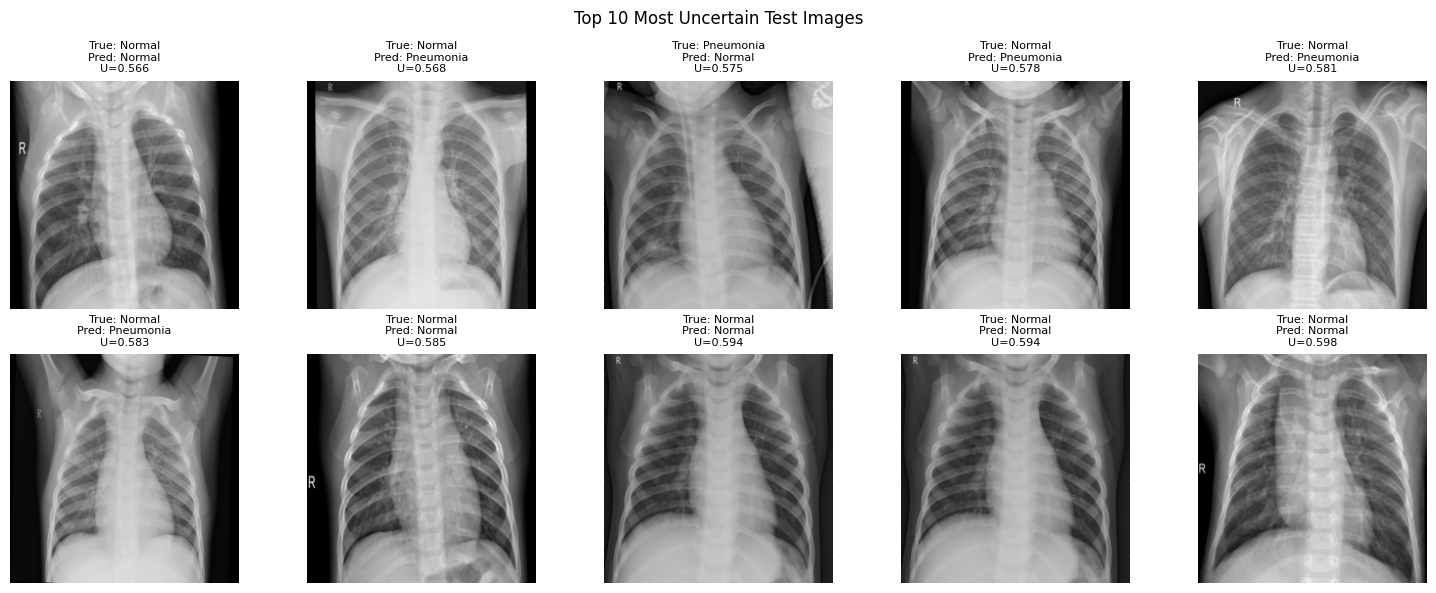

In [84]:
# Displaying the 10 most uncertain X rays
top10 = np.argsort(test_uncertainties)[-10:]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(15,6))

for i, idx in enumerate(top10):

    img = test_images[idx].permute(1,2,0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    true_label = "Normal" if test_labels[idx] == 0 else "Pneumonia"
    pred_label = "Normal" if test_preds[idx] == 0 else "Pneumonia"

    plt.title(
      f"True: {true_label}\n"
      f"Pred: {pred_label}\n"
      f"U={test_uncertainties[idx]:.3f}",
      fontsize=8
    )

    plt.axis("off")

plt.suptitle("Top 10 Most Uncertain Test Images")

plt.tight_layout()

plt.show()

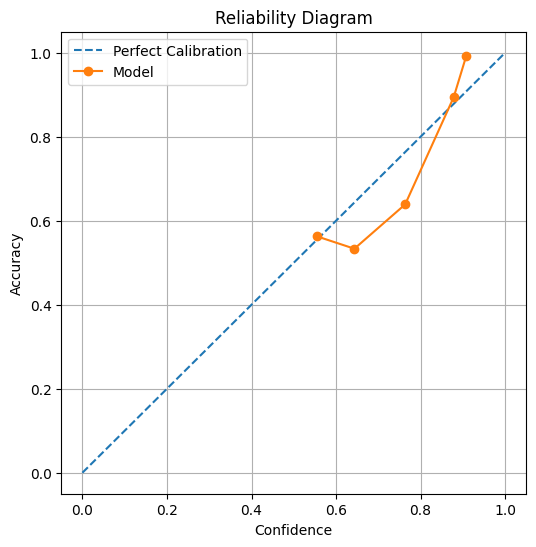

In [92]:
num_bins = 10

bins = np.linspace(0, 1, num_bins + 1)

bin_acc = []
bin_conf = []

test_correct = np.array(test_preds) == np.array(test_labels)

for i in range(num_bins):

    mask = (
        (np.array(test_confidences) >= bins[i]) &
        (np.array(test_confidences) < bins[i+1])
    )

    if np.sum(mask) > 0:

        bin_acc.append(
            np.mean(test_correct[mask])
        )

        bin_conf.append(
            np.mean(np.array(test_confidences)[mask])
        )

plt.figure(figsize=(6,6))

plt.plot(
    [0,1],
    [0,1],
    '--',
    label='Perfect Calibration'
)

plt.plot(
    bin_conf,
    bin_acc,
    'o-',
    label='Model'
)

plt.xlabel("Confidence")

plt.ylabel("Accuracy")

plt.title("Reliability Diagram")

plt.legend()

plt.grid(True)

plt.show()

In [93]:
ece = 0

N = len(test_confidences)

for i in range(num_bins):

    mask = (
        (np.array(test_confidences) >= bins[i]) &
        (np.array(test_confidences) < bins[i+1])
    )

    if np.sum(mask) > 0:

        acc = np.mean(test_correct[mask])

        conf = np.mean(np.array(test_confidences)[mask])

        ece += (
            np.sum(mask) / N
        ) * abs(acc - conf)

print(f"ECE: {ece:.4f}")

ECE: 0.0565


In [94]:
torch.save(model.state_dict(), "pneumonia_edl_3.pth")